In [1]:
from recommender_system.data.load import load_data
from recommender_system.data.transform import transform_reviews, train_test_split
from recommender_system.data.utils import get_reviews_per_game

import matplotlib.pyplot as plt

df = load_data('../data/australian_user_reviews.json.gz')
reviews = transform_reviews(df)
train, test = train_test_split(reviews, n_test=1)

reviews_per_game = get_reviews_per_game(reviews)

train.head()

,user_id,posted,item_id,recommend
58236,--ace--,2014-01-24,440,True
32158,--ionex--,2015-08-15,105600,True
45374,-2SV-vuLB-Kg,2014-10-07,440,True
45375,-2SV-vuLB-Kg,2014-10-15,200510,True
45373,-2SV-vuLB-Kg,2014-10-19,302510,True


In [2]:
from recommender_system.models.popular import recommend_popular


recommendations = recommend_popular(train, n=10)
recommendations.head(10)

,user_id,item_id
0,--ace--,730
1,--ace--,4000
2,--ace--,570
3,--ace--,304930
4,--ace--,218620
5,--ace--,550
6,--ace--,105600
7,--ace--,72850
8,--ace--,252490
9,--ace--,221100


In [15]:
recommendations.info()

<class 'pandas.DataFrame'>
RangeIndex: 32676 entries, 0 to 32675
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  32676 non-null  str  
 1   item_id  32676 non-null  str  
dtypes: str(2)
memory usage: 510.7 KB


# Eval Baseline popularity model
## n_test=1 
Recall@3: 0.1132 \
NDCG@3: 0.08329 \
\
Recall@10: 0.2022 \
NDCG@10: 0.1151


In [4]:
from recommender_system.utils import recall_at_k, ndcg_at_k

recall = recall_at_k(recommendations, test, k=10)
print(f"Recall@10: {recall:.4f}")

ndcg = ndcg_at_k(recommendations, test, k=10)
print(f"NDCG@10: {ndcg:.4f}")

Recall@10: 0.2022
NDCG@10: 0.1151


In [18]:
print("Train users:", train["user_id"].nunique())
print("Test users:", test["user_id"].nunique())
print("Train interactions:", len(train))
print("Test interactions:", len(test))
train.groupby("user_id").size().describe()

Train users: 10892
Test users: 10892
Train interactions: 28349
Test interactions: 10892


count    10892.000000
mean         2.602736
std          2.007973
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
dtype: float64

In [5]:
recoms_extra = recommendations.merge(reviews_per_game, on='item_id', how='left')

recoms_extra.head(10)

,user_id,item_id,num_positive,num_negative,total
0,--ace--,730,3478,281,3759
1,--ace--,4000,1685,50,1735
2,--ace--,570,1458,104,1562
3,--ace--,304930,961,89,1050
4,--ace--,218620,910,227,1137
5,--ace--,550,731,21,752
6,--ace--,105600,723,18,741
7,--ace--,72850,677,41,718
8,--ace--,252490,702,113,815
9,--ace--,221100,575,162,737


The popularity-based model only recommends a very narrow subset of all games available in the dataset

<Axes: title={'center': 'Most recommended games'}, xlabel='Game', ylabel='Count of recommendations'>

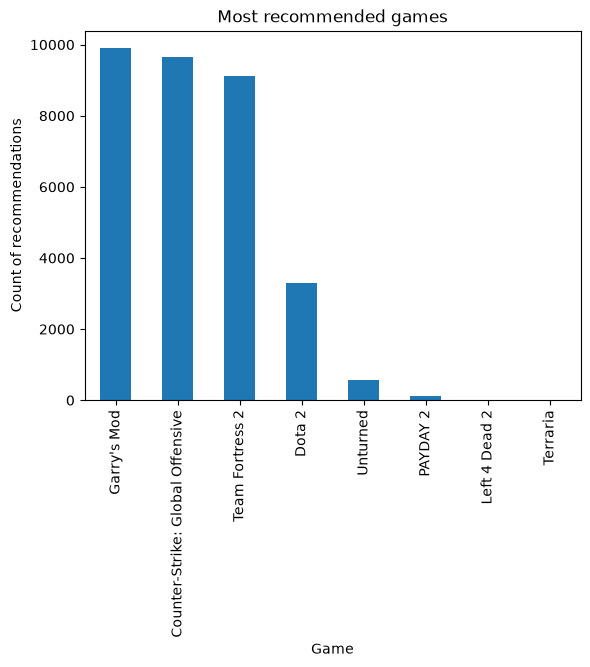

In [ ]:
recoms_extra.value_counts('app_name').plot.bar(title='Most recommended games popularity-based', xlabel='Game', ylabel='Count of recommendations')

## Collaborative filtering

In [6]:
from recommender_system.models.collaborative_filtering import get_item_similarity_matrix, recommend_item_cf

sims, item_to_idx = get_item_similarity_matrix(train)

recommendations = recommend_item_cf(train, sims, item_to_idx, n=10)

# Eval CF model
## n_test=1
Recall@3: 0.05206 \
NDCG@3: 0.03879 \
\
Recall@10: 0.1079 \
NDCG@10: 0.05873

In [8]:
recall = recall_at_k(recommendations, test, k=10)
print(f'Recall@10: {recall:.5f}')

ndcg = ndcg_at_k(recommendations, test, k=10)
print(f'NDCG@10: {ndcg:.5f}')

Recall@10: 0.10788
NDCG@10: 0.05873


Item-item collaborative filtering gives a much richer set of recommended games but gets a lower recall score

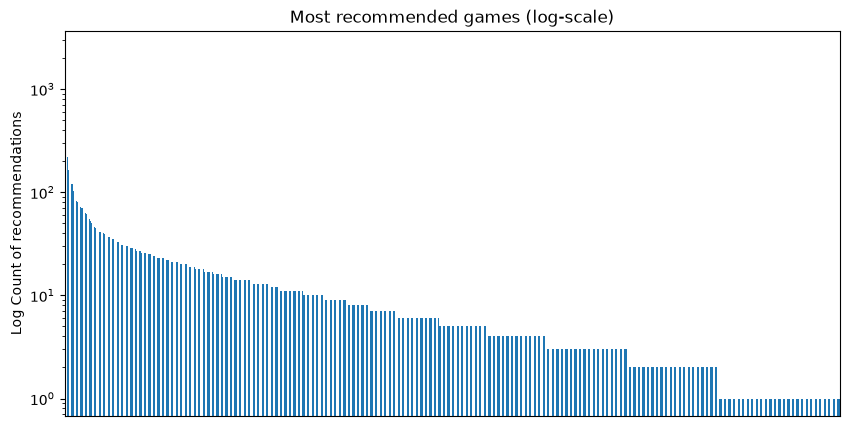

In [ ]:
recoms_extra_cf = recommendations.merge(reviews_per_game, on='item_id', how='left')
fig, ax = plt.subplots(figsize=(10, 5))
recoms_extra_cf.value_counts('app_name').plot.bar(title='Most recommended games CF(log-scale)', xlabel='Game', ylabel='Log Count of recommendations')
ax.xaxis.set_visible(False)
ax.set_yscale('log')

## Matrix Factorization

In [9]:
from recommender_system.models.matrixfactorization import MatrixFactorization, recommend_mf
from recommender_system.models.collaborative_filtering import df2interact_mat

interactions, item_to_idx, user_to_idx = df2interact_mat(train, 'user_id', 'item_id', 'recommend')

model = MatrixFactorization(n_factors=25, random_state=42)
model.fit(interactions, n_epochs=10, learning_rate=0.01, regularization=0)

Epoch 1/10, RMSE: 1.0268
Epoch 2/10, RMSE: 1.0218
Epoch 3/10, RMSE: 1.0166
Epoch 4/10, RMSE: 1.0105
Epoch 5/10, RMSE: 1.0026
Epoch 6/10, RMSE: 0.9919
Epoch 7/10, RMSE: 0.9764
Epoch 8/10, RMSE: 0.9548
Epoch 9/10, RMSE: 0.9271
Epoch 10/10, RMSE: 0.8963


In [10]:
recommendations = recommend_mf(model, test, train, user_to_idx, {idx: item for item, idx in item_to_idx.items()}, n=10)
recommendations.head(10)

,user_id,item_id,score
0,--ace--,730,0.590259
1,--ace--,304930,0.539621
2,--ace--,4000,0.485933
3,--ace--,105600,0.282801
4,--ace--,72850,0.242582
5,--ace--,49520,0.241974
6,--ace--,252490,0.200606
7,--ace--,230410,0.191838
8,--ace--,251430,0.186158
9,--ace--,203290,0.175979


# Eval MF model
## n_test=1
Recall@3: 0.06069 \
NDCG@3: 0.0465 \
\
Recall@10: 0.1015 \
NDCG@10: 0.06124

In [11]:
from recommender_system.utils import recall_at_k, ndcg_at_k
recall = recall_at_k(recommendations, test, k=10)
print(f'Recall@10: {recall:.5f}')

ndcg = ndcg_at_k(recommendations, test, k=10)
print(f'NDCG@10: {ndcg:.5f}')

Recall@10: 0.10145
NDCG@10: 0.06124


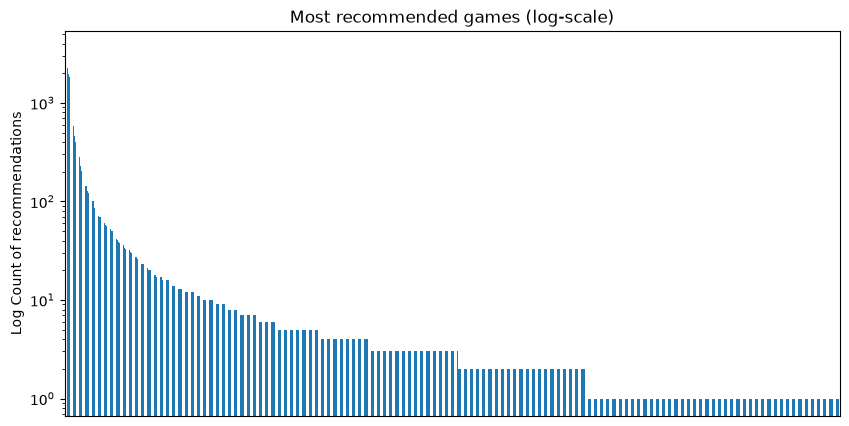

In [ ]:
recoms_extra_mf = recommendations.merge(reviews_per_game, on='item_id', how='left')
fig, ax = plt.subplots(figsize=(10, 5))
recoms_extra_mf.value_counts('app_name').plot.bar(title='Most recommended games MF (log-scale)', xlabel='Game', ylabel='Log Count of recommendations')
ax.xaxis.set_visible(False)
ax.set_yscale('log')